[ 0.848 -0.242]


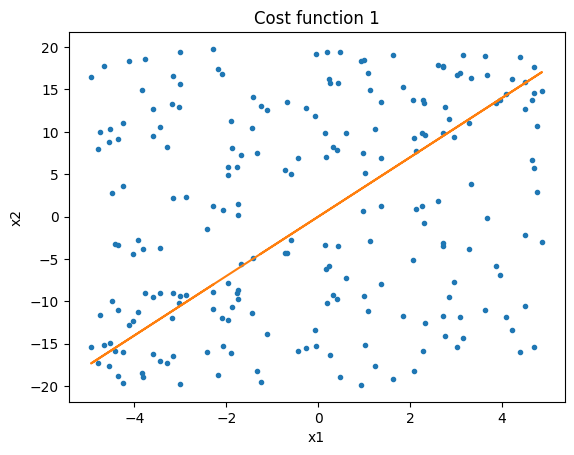

[ 0.857 -0.289  0.987]


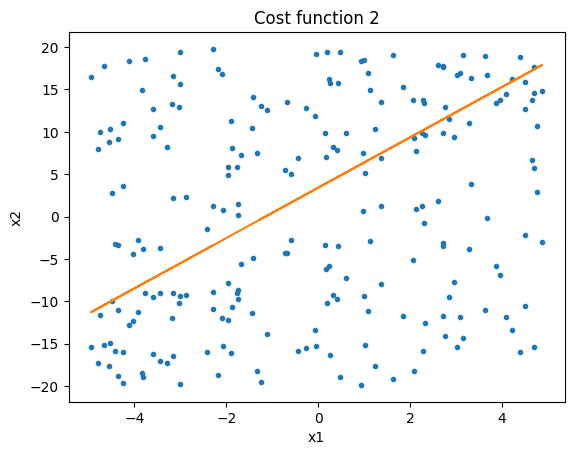

[ 0.849 -0.312]


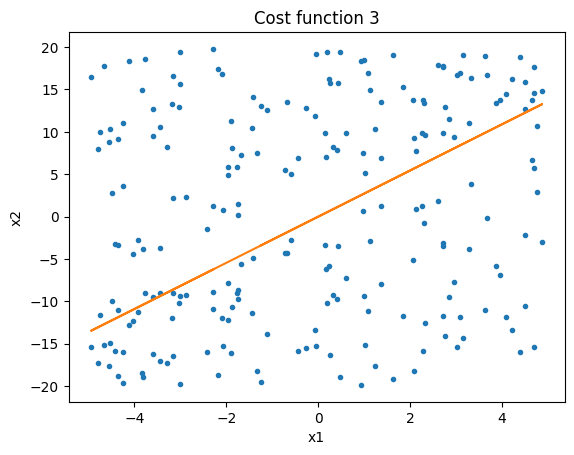

[ 0.861 -0.307  0.987]


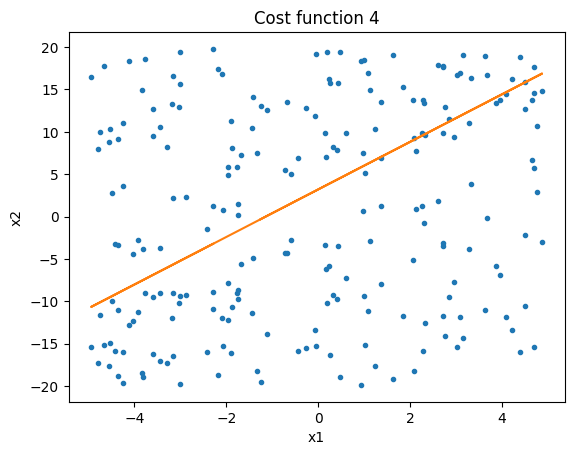

In [45]:
import numpy as np
np.set_printoptions(precision = 3, suppress = True)
import pandas as pd
import matplotlib.pyplot as mp

def grad_cf1(y,X,w):
  n = y.shape[0]
  grad = np.zeros(2)
  for p in range(n):
    check = y[p]*(X[p,0]*w[0]+X[p,1]*w[1])
    if check <0:
      grad[0]-=y[p]*X[p,0]
      grad[1]-=y[p]*X[p,1]
  return grad/n

def grad_cf2(y,X,w,lda):
  n = y.shape[0]
  grad = np.zeros(3)
  grad[0] = 2*lda*w[0]
  grad[1] = 2*lda*w[1]
  for p in range(n):
    check = y[p]*(X[p,0]*w[0]+X[p,1]*w[1])
    sigma = np.exp(-y[p]*w[2] - check)
    grad[0]-=y[p]*X[p,0]*sigma/(1+sigma)/n
    grad[1]-=y[p]*X[p,1]*sigma/(1+sigma)/n
    grad[2]-=y[p]*sigma/(1+sigma)/n
  return grad

def grad_cf3(y,X,w):
  n = y.shape[0]
  grad = np.zeros(2)
  for p in range(n):
    check = y[p]*(X[p,0]*w[0]+X[p,1]*w[1])
    if check <1:
      grad[0]-=y[p]*X[p,0]
      grad[1]-=y[p]*X[p,1]
  return grad/n

def grad_cf4(y,X,w,lda):
  n = y.shape[0]
  grad = np.zeros(3)
  grad[0] = 2*lda*w[0]
  grad[1] = 2*lda*w[1]
  for p in range(n):
    check_new = 1-y[p]*(w[2] + X[p,0]*w[0]+X[p,1]*w[1])
    if check_new >0:
      grad[0]-=y[p]*X[p,0]/n
      grad[1]-=y[p]*X[p,1]/n
      grad[2]-=y[p]/n
  return grad

dat = pd.read_csv('/content/dataset_lab10.csv').values
x = dat[:,0:2]
y = dat[:,2]
N = len(x)
s = 1e-3 #learning rate
eps = 1e-3 #error threshold
lda = 1e-3

# Cost function 1
w = np.ones(2)
wold = np.zeros(2)
iter = 0

while np.linalg.norm(w-wold) > eps:
  iter+=1
  wold = w
  grad = grad_cf1(y,x,w)
  w = wold-s*grad
print(w)

mp.plot(x[:,0],x[:,1], '.')
mp.plot(x[:,0],-w[0]*x[:,0]/w[1])
mp.xlabel('x1')
mp.ylabel('x2')
mp.title('Cost function 1')
mp.show()

# Cost function 2
w = np.ones(3)
wold = np.zeros(3)

while np.linalg.norm(w-wold) > eps:
  wold = w
  grad = grad_cf2(y,x,w,lda)
  w = wold-s*grad
print(w)

mp.plot(x[:,0],x[:,1], '.')
mp.plot(x[:,0],-(w[0]*x[:,0]+w[2])/w[1])
mp.xlabel('x1')
mp.ylabel('x2')
mp.title('Cost function 2')
mp.show()

# Cost function 3
w = np.ones(2)
wold = np.zeros(2)
iter = 0

while np.linalg.norm(w-wold) > eps:
  iter += 1
  wold = w
  grad = grad_cf3(y,x,w)
  w = wold-s*grad
print(w)

mp.plot(x[:,0],x[:,1], '.')
mp.plot(x[:,0],-w[0]*x[:,0]/w[1])
mp.xlabel('x1')
mp.ylabel('x2')
mp.title('Cost function 3')
mp.show()

# Cost function 4
w = np.ones(3)
wold = np.zeros(3)
iter = 0

while np.linalg.norm(w-wold) > eps:
  iter += 1
  wold = w
  grad = grad_cf4(y,x,w,lda)
  w = wold-s*grad
print(w)

mp.plot(x[:,0],x[:,1], '.')
mp.plot(x[:,0],-(w[0]*x[:,0]+w[2])/w[1])
mp.xlabel('x1')
mp.ylabel('x2')
mp.title('Cost function 4')
mp.show()

